# Consolidated Uncertainty Analysis: Ammonia Production Case Study

This notebook provides a comprehensive uncertainty analysis workflow for the ammonia production system, including:

1. **Case Study Setup**: Database initialization and PULPO configuration
2. **Chance-Constrained Pareto Optimization**: Solving the CC-Pareto problem
3. **Monte Carlo Analysis - Custom Strategies**: 100 iterations with expert knowledge and bounds
4. **Monte Carlo Analysis - Fitted Normal Distributions**: 100 iterations with transformed distributions
5. **Monte Carlo Analysis - Ecoinvent Uncertainties**: 100 iterations using only B and Q matrices

All intermediate results are saved as pickle files and automatically reloaded if they exist.

## Configuration Parameters

Set these parameters to control the notebook behavior:

In [1]:
# ===========================
# CONFIGURATION PARAMETERS
# ===========================

# Force recalculation of all results (ignore cached files)
FORCE_RECALCULATION = False

# Number of Monte Carlo iterations
N_MC_ITERATIONS = 300

# Random seed for reproducibility
RANDOM_SEED = 666

# Solver configuration
SOLVER_NAME = "highs"

# File paths for saved results
RESULTS_DIR = "data/results"
CC_PARETO_FILE = f"{RESULTS_DIR}/cc_pareto_results.pkl"
MC_STRATEGIES_FILE = f"{RESULTS_DIR}/mc_uncertainty_strategies.pkl"
MC_NORMAL_FILE = f"{RESULTS_DIR}/mc_fitted_normal.pkl"
MC_ECOINVENT_FILE = f"{RESULTS_DIR}/mc_ecoinvent_only.pkl"

# Cutoff for uncertainty filtering
UNCERTAINTY_CUTOFF = 0.000019

# Number of top processes to plot
N_TOP_PROCESSES = 19

print("✓ Notebook execution completed successfully!")

✓ Notebook execution completed successfully!


## Import Required Libraries

In [2]:
%load_ext autoreload
%autoreload 2

import os
import sys
import pickle
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ensure results directory exists
os.makedirs(RESULTS_DIR, exist_ok=True)

# Add parent directory to path
sys.path.append('..')

# Import PULPO modules
from pulpo import pulpo
from pulpo.utils.uncertainty import preparer, processor, plots, gsa
from pulpo.utils import optimizer, saver

# Brightway imports
import bw2data as bd
import bw2io as bi

print("All libraries imported successfully!")

All libraries imported successfully!


## 0. Helper Functions

### 0.1: Database Setup Functions

In [3]:
def read_credentials(path: Path):
    """Read ecoinvent credentials from a text file."""
    if not path.is_file():
        raise FileNotFoundError(f"Couldn't find credentials file at: {path.resolve()}")
    creds = {}
    for raw in path.read_text().splitlines():
        line = raw.strip()
        if not line or line.startswith("#"):
            continue
        # allow "key=value" or "key: value" or "key value"
        for sep in ("=", ":", " "):
            if sep in line:
                k, v = line.split(sep, 1)
                creds[k.strip().lower()] = v.strip()
                break
    if "username" not in creds or "password" not in creds:
        raise ValueError("credentials.txt must contain 'username' and 'password'.")
    return creds["username"], creds["password"]

def setup_ecoinvent_database(project_name, db_name, cred_path):
    """Setup Ecoinvent database in Brightway project."""
    bd.projects.set_current(project_name)
    
    if db_name in bd.databases:
        print(f"Database '{db_name}' already exists in project '{bd.projects.current}'.")
        return
    
    print(f"Importing '{db_name}' database...")
    username, password = read_credentials(cred_path)
    bi.import_ecoinvent_release(
        version="3.10",
        system_model="cutoff",
        username=username,
        password=password,
    )
    print(f"Database '{db_name}' installed successfully.")

def setup_foreground_database(excel_path, fg_db_name, bg_db_name):
    """Setup foreground database from Excel file."""
    if fg_db_name in bd.databases:
        print(f"Database '{fg_db_name}' already exists in project '{bd.projects.current}'.")
        return
    
    print(f"Importing foreground database from {excel_path}...")
    fg_db = bi.ExcelImporter(excel_path)
    fg_db.apply_strategies()
    fg_db.match_database(fields=["name", "unit", "reference product", "location"])
    fg_db.match_database(bg_db_name, fields=["name", "unit", "location", "reference product"])
    
    biosphere_db = [db for db in bd.databases if "biosphere" in db and "3.10" in db][0]
    fg_db.match_database(biosphere_db, fields=["name", "categories", "location"])
    
    fg_db.statistics()
    fg_db.write_database()
    print(f"Database '{fg_db_name}' installed successfully.")

def setup_impact_methods():
    """Setup required impact assessment methods."""
    # Check IPCC 2021 method
    target_method_2021 = ('IPCC 2021', 'climate change', 'GWP 100a, incl. H and bio CO2')
    if target_method_2021 not in bd.methods:
        print(f"Adding premise GWP characterization factors...")
        from premise_gwp import add_premise_gwp
        add_premise_gwp()
        print("Premise GWP added successfully.")
    else:
        print(f"Method '{target_method_2021}' already exists.")
    
    # Check IPCC 2013 uncertain method
    target_method_2013 = ('IPCC 2013', 'climate change', 'global warming potential (GWP100)', 'uncertain')
    if target_method_2013 not in bd.methods:
        print(f"Importing IPCC 2013 GWP method with uncertainty...")
        from bw2io.package import BW2Package
        BW2Package.import_file("data/ipcc_uncertain.bw2package")
        print("IPCC 2013 GWP with uncertainty added successfully.")
    else:
        print(f"Method '{target_method_2013}' already exists.")

### 0.2: Case Study Setup Functions

In [4]:
def setup_ammonia_case_study():
    """Set up the ammonia production case study with PULPO configuration."""
    project = "ammonia_final"
    database = ["ecoinvent-3.10-cutoff", "ammonia"]
    method = "('IPCC 2013', 'climate change', 'global warming potential (GWP100)', 'uncertain')"
    directory = "develop_tests"
    
    return project, database, method, directory

def create_pulpo_worker(project, database, method, directory):
    """Create and initialize a PULPO optimizer instance."""
    pulpo_worker = pulpo.PulpoOptimizer(project, database, method, directory)
    pulpo_worker.intervention_matrix = "ecoinvent-3.10-biosphere"
    pulpo_worker.get_lci_data()
    
    return pulpo_worker

def get_single_process(worker, query, prefer_locations=("RER", "Europe", "GLO")):
    """Deterministic process retrieval to avoid order issues."""
    matches = worker.retrieve_processes(processes=query)
    if not matches:
        raise ValueError(f"No process found for query: {query}")
    for loc in prefer_locations:
        for p in matches:
            if getattr(p, "location", None) == loc or loc in str(p):
                return p
    return sorted(matches, key=lambda x: str(x))[0]

def define_ammonia_problem(pulpo_worker):
    """Define the ammonia production optimization problem."""
    # Choice definitions with capacities
    choice_config = {
        "biogas": {
            "processes": [
                "anaerobic digestion of agricultural residues",
                "anaerobic digestion of sequential crop",
            ],
            "capacities": [1.60e10, 1.40e10],
        },
        "biomethane": {
            "processes": [
                "upgrading water scrubbing (CCS)",
                "upgrading water scrubbing",
                "upgrading chemical scrubbing",
                "upgrading chemical scrubbing (CCS)",
            ],
            "capacities": [1e20, 1e20, 1e20, 1e20],
        },
        "methane": {
            "processes": ["market for methane fg", "market for biomethane"],
            "capacities": [1e20, 1e20],
        },
        "heat": {
            "processes": ["heat from methane", "heat from methane (CCS)", "heat from hydrogen"],
            "capacities": [1e20, 1e20, 1e20],
        },
        "hydrogen": {
            "processes": [
                "methane pyrolysis",
                "steam methane reforming",
                "steam methane reforming (CCS)",
                "plastics gasification",
                "plastics gasification (CCS)",
                "alkaline electrolysis",
                "PEM electrolysis",
            ],
            "capacities": [1e20, 1e20, 1e20, 1e20, 1e20, 1e20, 1e20],
        },
        "electricity": {
            "processes": ["grid electricity"],
            "capacities": [1e20],
        },
        "ammonia": {
            "processes": [
                "steam reforming, integrated",
                "steam reforming, integrated (CCS)",
                "nitrogen + hydrogen",
            ],
            "capacities": [1e20, 1e20, 1e20],
        },
    }

    # Build choices with deterministic mapping
    choices = {}
    for category, cfg in choice_config.items():
        labels, caps = cfg["processes"], cfg["capacities"]
        if len(labels) != len(caps):
            raise ValueError(f"Length mismatch in '{category}': {len(labels)} labels vs {len(caps)} capacities")
        choices[category] = {get_single_process(pulpo_worker, lbl): cap for lbl, cap in zip(labels, caps)}

    # Demand (EU ammonia, kg/yr)
    demand_process = get_single_process(pulpo_worker, "market for ammonia")
    demand = {demand_process: 17.1e9}

    # Additional upper bounds
    waste_pp = get_single_process(pulpo_worker, "treatment of waste PP")
    waste_ps = get_single_process(pulpo_worker, "treatment of waste PS")
    ccs_process = get_single_process(pulpo_worker, "CCS 200km pipeline 1000m deep")

    upper_bounds = {
        waste_pp: 1e20,
        waste_ps: 1e20,
        ccs_process: 1e20,
    }
    
    return choices, demand, upper_bounds

### 0.3: Analysis and Visualization Functions

In [ ]:
def analyze_MC_results(results_MC, impact_method=None, show_plot=True):
    """
    Analyze Monte Carlo results from PulloOptimizer.
    
    Args:
        results_MC (dict): Monte Carlo results dictionary
        impact_method (str or tuple): Impact method to analyze
        show_plot (bool): Whether to display histogram
        
    Returns:
        dict: Analysis results including statistics and choices
    """
    impacts = {}
    choices_data = []

    for i, result in results_MC.items():
        if not result or "Impacts" not in result:
            continue

        imp_df = result["Impacts"]
        if imp_df is None or imp_df.empty:
            continue

        # Auto-select the first method if none given
        if impact_method is None:
            impact_method = imp_df.index[0]
        
        if impact_method in imp_df.index:
            impacts[i] = imp_df.loc[impact_method, "Value"]
        else:
            continue

        # Extract choices
        choices_dict = result.get("Choices", {})
        for tech, df in choices_dict.items():
            if isinstance(df, pd.DataFrame):
                chosen = df[df["Value"] > 0]
                for meta, row in chosen.iterrows():
                    choices_data.append({
                        "iteration": i,
                        "technology": tech,
                        "process": meta,
                        "value": row["Value"]
                    })

    # Convert to DataFrames
    impacts_series = pd.Series(impacts, name="Impact Value")
    choices_df = pd.DataFrame(choices_data)

    # Compute statistics
    impact_stats = impacts_series.describe()

    # Aggregate choice frequency
    if not choices_df.empty:
        choices_summary = (
            choices_df.groupby(["technology", "process"])
            .agg(
                times_chosen=("iteration", "count"),
                avg_value=("value", "mean")
            )
            .sort_values("times_chosen", ascending=False)
        )
    else:
        choices_summary = pd.DataFrame()

    # Plot histogram
    if show_plot and not impacts_series.empty:
        plt.figure(figsize=(8, 5))
        plt.hist(impacts_series, bins=25, edgecolor="black", alpha=0.7)
        plt.title("Monte Carlo Impacts Distribution")
        plt.xlabel("Impact Value")
        plt.ylabel("Frequency")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    print("\n" + "="*60)
    print("MONTE CARLO ANALYSIS RESULTS")
    print("="*60)
    print("\nImpact Statistics:")
    print("-" * 60)
    print(impact_stats.round(3))
    print("\nTop Choices (by frequency):")
    print("-" * 60)
    if not choices_summary.empty:
        print(choices_summary.head(10))
    else:
        print("No active choices found.")
    print("="*60 + "\n")

    return {
        "impact_stats": impact_stats,
        "impact_values": impacts_series,
        "choices_summary": choices_summary,
    }

def save_results(data, filepath):
    """Save results to pickle file."""
    with open(filepath, 'wb') as f:
        pickle.dump(data, f)
    print(f"✓ Results saved to: {filepath}")

def load_results(filepath):
    """Load results from pickle file."""
    with open(filepath, 'rb') as f:
        data = pickle.load(f)
    print(f"✓ Results loaded from: {filepath}")
    return data

def check_file_exists(filepath):
    """Check if results file exists."""
    return os.path.exists(filepath) and not FORCE_RECALCULATION

## 1. Database and Project Setup

### 1.1: Initialize Databases

In [6]:
# Configuration for database setup
PROJECT = "ammonia_final"
DB_NAME = "ecoinvent-3.10-cutoff"
CRED_PATH = Path("/Users/hausslingbhl/Library/CloudStorage/OneDrive-UniversiteitLeiden/01_Administration/02_VITO/04_Systems/credentials.txt")

# Setup ecoinvent database
setup_ecoinvent_database(PROJECT, DB_NAME, CRED_PATH)

# Setup foreground database
excel_path = r"data/ammonia.xlsx"
fg_db_name = "ammonia"
setup_foreground_database(excel_path, fg_db_name, DB_NAME)

# Setup impact methods
setup_impact_methods()

print("\n✓ All databases and methods are ready!")

Database 'ecoinvent-3.10-cutoff' already exists in project 'ammonia_final'.
Database 'ammonia' already exists in project 'ammonia_final'.
Method '('IPCC 2021', 'climate change', 'GWP 100a, incl. H and bio CO2')' already exists.
Method '('IPCC 2013', 'climate change', 'global warming potential (GWP100)', 'uncertain')' already exists.

✓ All databases and methods are ready!


### 1.2: Initialize PULPO Worker

In [7]:
# Set up case study parameters
project, database, method, directory = setup_ammonia_case_study()

# Create PULPO worker
pulpo_worker = create_pulpo_worker(project, database, method, directory)

# Define the optimization problem
choices, demand, upper_bounds = define_ammonia_problem(pulpo_worker)

# Instantiate the problem
pulpo_worker.instantiate(demand=demand, choices=choices, upper_limit=upper_bounds)

print("\n✓ PULPO worker initialized and problem instantiated!")

Creating Instance
Instance created

✓ PULPO worker initialized and problem instantiated!
Instance created

✓ PULPO worker initialized and problem instantiated!


In [8]:
pulpo_worker.solve()

optimal solution found:  -17790761460.726955


## 2. Chance-Constrained Pareto Optimization

This section solves the Chance-Constrained (CC) Pareto optimization problem and saves the results.

Running CC-Pareto optimization...
chosen environmental impact method: ('IPCC 2013', 'climate change', 'global warming potential (GWP100)', 'uncertain')
The total impact is: 4.750512e+01
chosen environmental impact method: ('IPCC 2013', 'climate change', 'global warming potential (GWP100)', 'uncertain')
The total impact is: 4.750512e+01


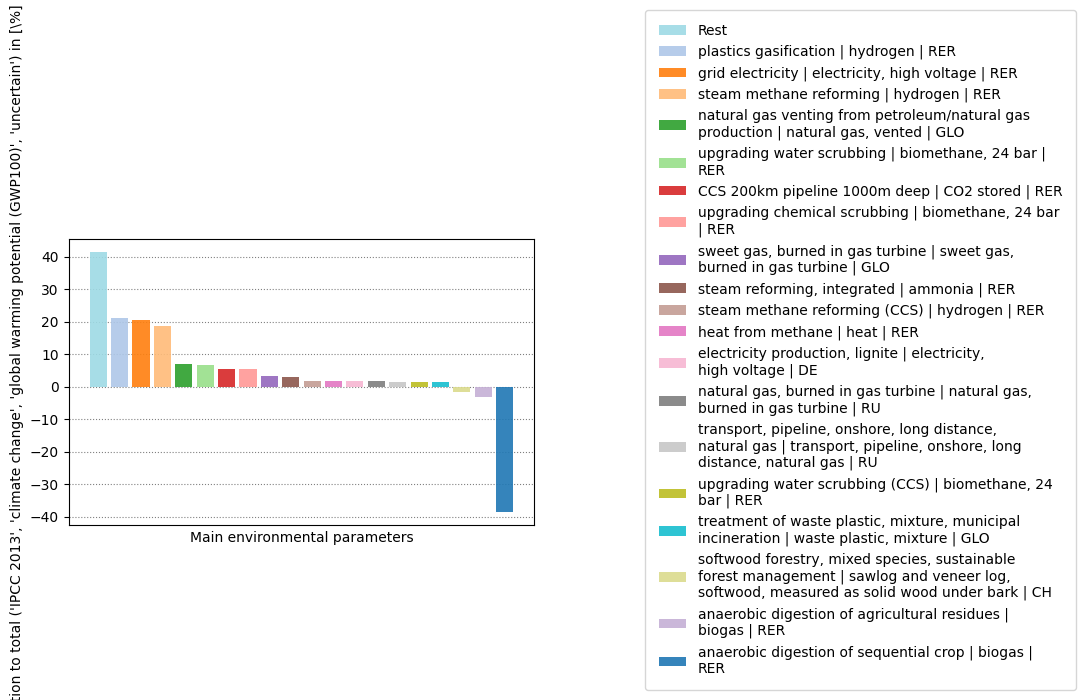

Characterized inventory: (2648, 23569) 21178
Filtered characterized inventory: (2648, 23569) 932
Deviation from LCA score: 0.009637170673559292
inventory (2648, 23569) filtering resulted in 932 of 21178 exchanges (99.04% of total impact) and took 0.001 seconds.
CHARACTERIZATION MATRIX (2648,) filtering resulted in 27 of 91 characterization factors
Intervention flows:
In ecoinvent-3.10-cutoff:
Parameters with uncertainty information: 814 
Parameters without uncertainty information: 78
In ammonia:
Parameters with uncertainty information: 814 
Parameters without uncertainty information: 78
In ammonia:
Parameters with uncertainty information: 0 
Parameters without uncertainty information: 40
Charactetization factors:
Parameters with uncertainty information: 14 
Parameters without uncertainty information: 13
Variable bounds:
Upper bound from choices without uncertainty information: 22
Upper bound from `upper_limit` without uncertainty information: 3
Lower bound from `lower_limit` without un

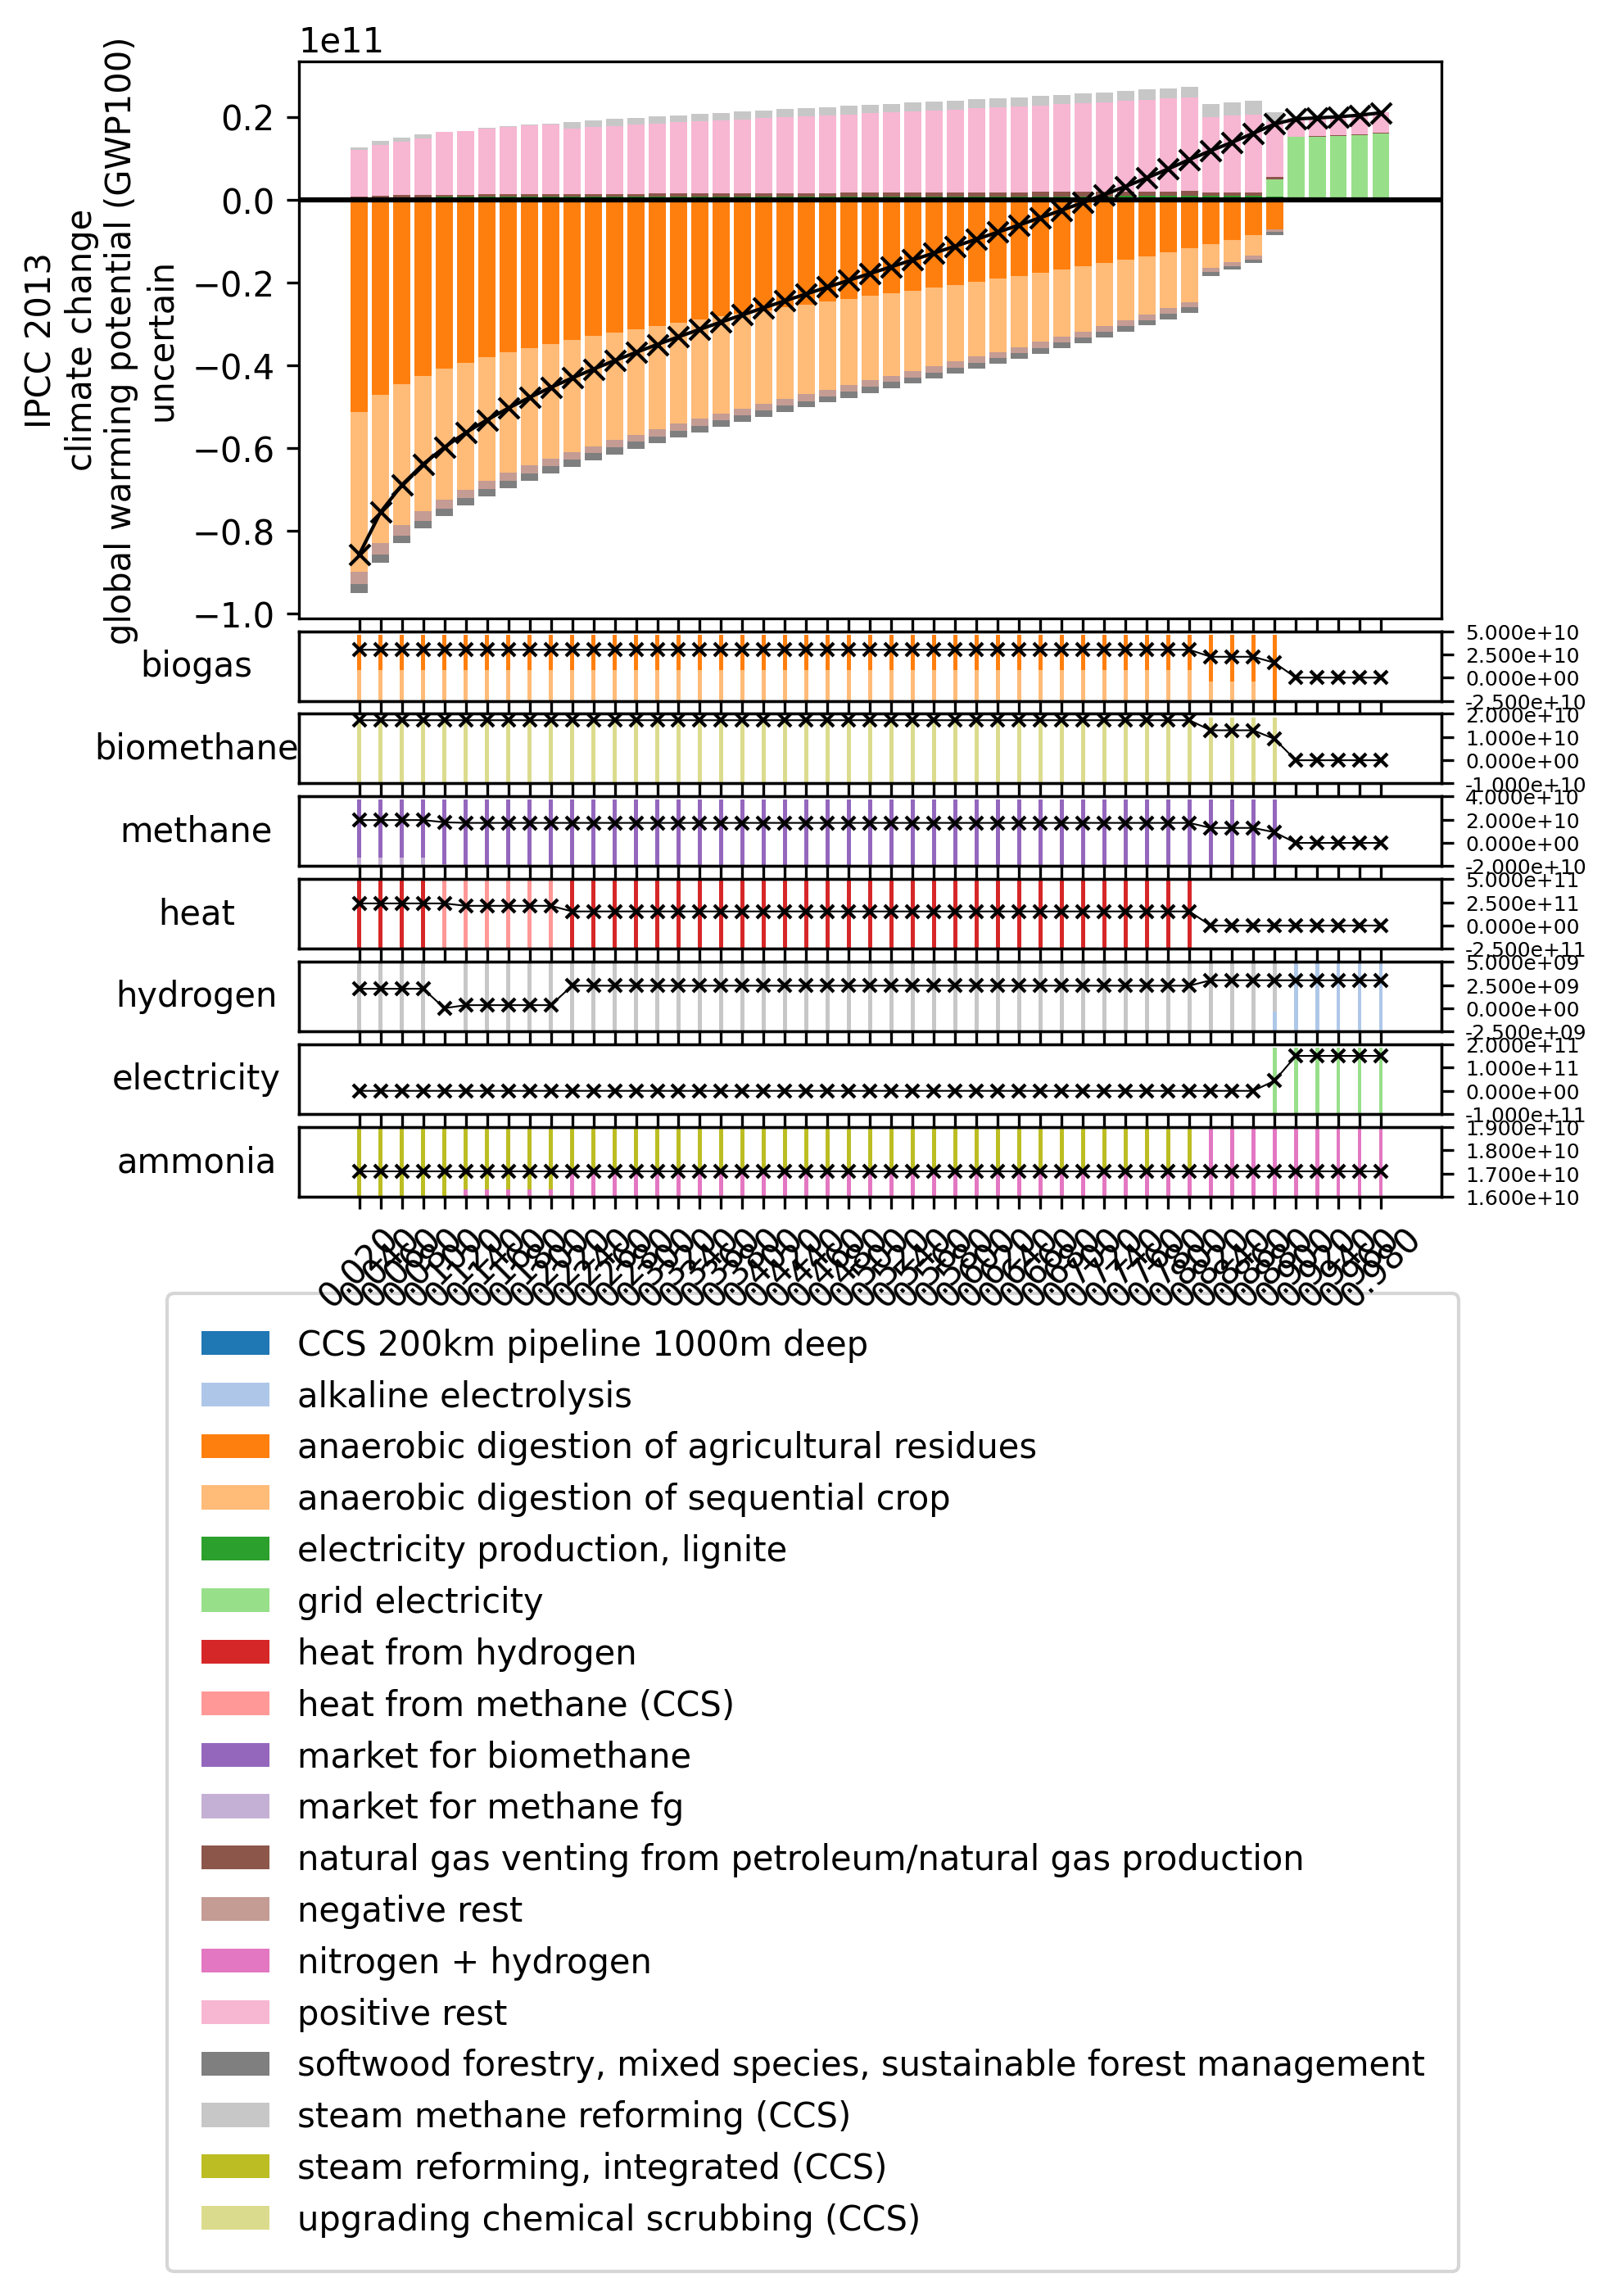

In [9]:
# Check if CC-Pareto results already exist
if check_file_exists(CC_PARETO_FILE):
    print(f"Loading existing CC-Pareto results from {CC_PARETO_FILE}...")
    cc_pareto_results = load_results(CC_PARETO_FILE)
else:
    print("Running CC-Pareto optimization...")
    
    # Define uncertainty strategies for CC formulation
    unc_strategies = [
        processor.TriangularBoundInterpolationStrategy(
            uncertain_param_type='If',
            uncertain_param_subgroup='ecoinvent-3.10-cutoff',
            noise_interval={'min': 0.1, 'max': 0.1}
        ),
        processor.UniformBaseStrategy(
            uncertain_param_type='If',
            uncertain_param_subgroup='ammonia',
            upper_scaling_factor=0.5,
            lower_scaling_factor=0.5,
            noise_interval={'min': 0.2, 'max': 0.2}
        ),
        processor.ExpertKnowledgeStrategy(
            uncertain_param_type='If',
            uncertain_param_subgroup='ammonia',
            prob_metadata={
                (715, 23523): {'loc': -2.622585, 'scale': 0.8, 'uncertainty_type': 2}, # CO2 emissions from [CCS 200km pipeline 1000m deep]
                (81, 23537): {'loc': -5.171644, 'scale': 0.1, 'uncertainty_type': 2}, # Carbon dioxide, in air | ('natural resource', 'in air')
                (82, 23537): {'loc': -4.678482, 'scale': 0.1, 'uncertainty_type': 2}, # Carbon dioxide, non-fossil | ('air', 'urban air close to ground')
                (716, 23537): {'loc': -2.718564, 'scale': 0.1, 'uncertainty_type': 2}, # Carbon dioxide, fossil | ('air', 'non-urban air or from high stacks')
            }
        )
    ]
    
    # Import and filter uncertainty data
    pulpo_worker.import_and_filter_uncertainty_data(
        cutoff=UNCERTAINTY_CUTOFF,
        scaling_vector_strategy='constructed_demand',
        plot_results=True,
        plot_n_top_processes=N_TOP_PROCESSES
    )
    
    # Apply uncertainty strategies
    pulpo_worker.apply_uncertainty_strategies(strategies=unc_strategies, drop_undefined=True)
    
    # Create CC formulation
    normal_metadata_env_cost, normal_metadata_var_bounds = pulpo_worker.create_CC_formulation(
        CC_env_cost=True,
        CC_var_bounds=['upper_limit']
    )
    
    # Solve CC-Pareto problem using epsilon-constraint method
    lambda_epsilon_array = np.arange(0.02, 1, 0.02)
    results_CC = pulpo_worker.solve_CC_problem(
        lambda_epsilon_array, 
        normal_metadata_env_cost, 
        normal_metadata_var_bounds, 
        solver_name=SOLVER_NAME
    )
    
    # Package results
    cc_pareto_results = {
        'results_CC': results_CC,
        'lambda_epsilon_array': lambda_epsilon_array,
        'normal_metadata_env_cost': normal_metadata_env_cost,
        'normal_metadata_var_bounds': normal_metadata_var_bounds,
        'uncertainty_data': pulpo_worker.uncertainty_data
    }
    
    # Save results
    save_results(cc_pareto_results, CC_PARETO_FILE)
    
    print("✓ CC-Pareto optimization completed!")

# Display results summary
print("\nCC-Pareto Results Summary:")
print("-" * 60)
print(f"Generated {len(cc_pareto_results['results_CC'])} Pareto points")
print(f"Lambda-epsilon range: {cc_pareto_results['lambda_epsilon_array'][0]:.2f} to {cc_pareto_results['lambda_epsilon_array'][-1]:.2f}")

# Plot Pareto front
try:
    plots.plot_pareto_front(
        result_data_CC=cc_pareto_results['results_CC'], 
        cutoff_value=0.015, 
        method="\n".join(method.split("'")[1::2]), 
        process_map_metadata=pulpo_worker.lci_data['process_map_metadata'], 
        bbox_to_anchor=(0.45, -3.),
        cmap_name='tab20',
        group_act_by='process'
    )
    print("✓ Pareto front plotted successfully!")
except Exception as e:
    print(f"Note: Could not plot Pareto front - {e}")
    print("Results are still saved and available for analysis.")

## 3. Monte Carlo Analysis - Custom Uncertainty Strategies

This section runs Monte Carlo simulations using custom uncertainty strategies with expert knowledge and bounds.

Running Monte Carlo analysis with custom strategies (300 iterations)...
Creating Instance
Instance created
Instance created
chosen environmental impact method: ('IPCC 2013', 'climate change', 'global warming potential (GWP100)', 'uncertain')
The total impact is: 4.750512e+01
Characterized inventory: (2648, 23569) 21178
Filtered characterized inventory: (2648, 23569) 932
chosen environmental impact method: ('IPCC 2013', 'climate change', 'global warming potential (GWP100)', 'uncertain')
The total impact is: 4.750512e+01
Characterized inventory: (2648, 23569) 21178
Filtered characterized inventory: (2648, 23569) 932
Deviation from LCA score: 0.009637170673559292
inventory (2648, 23569) filtering resulted in 932 of 21178 exchanges (99.04% of total impact) and took 1.439 seconds.
CHARACTERIZATION MATRIX (2648,) filtering resulted in 27 of 91 characterization factors
Intervention flows:
In ecoinvent-3.10-cutoff:
Deviation from LCA score: 0.009637170673559292
inventory (2648, 23569) filterin

Sampling uncertainty draws: 100%|██████████| 300/300 [00:20<00:00, 14.39it/s]


Running 300 Monte Carlo optimizations in parallel (n_jobs=-1).


Monte Carlo solve: 100%|██████████| 300/300 [27:07<00:00,  5.43s/it]



✓ Results saved to: data/results/mc_uncertainty_strategies.pkl
✓ MC analysis with strategies completed!

Analyzing MC results with custom strategies...


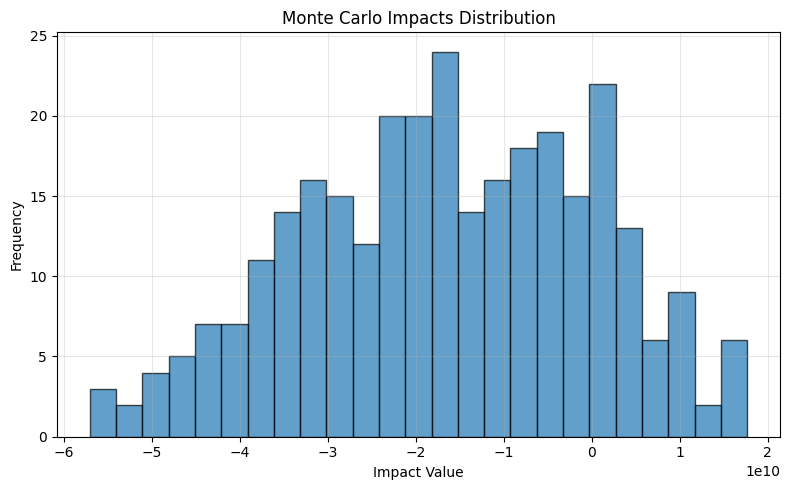


MONTE CARLO ANALYSIS RESULTS

Impact Statistics:
------------------------------------------------------------
count    3.000000e+02
mean    -1.654619e+10
std      1.651506e+10
min     -5.709002e+10
25%     -2.904521e+10
50%     -1.709688e+10
75%     -3.674100e+09
max      1.767331e+10
Name: Impact Value, dtype: float64

Top Choices (by frequency):
------------------------------------------------------------
                                                               times_chosen  \
technology process                                                            
ammonia    nitrogen + hydrogen | ammonia | RER                          299   
methane    market for biomethane | biomethane, 24 bar | RER             294   
biogas     anaerobic digestion of agricultural residues | ...           283   
biomethane upgrading chemical scrubbing (CCS) | biomethane...           274   
biogas     anaerobic digestion of sequential crop | biogas...           273   
hydrogen   steam methane reforming 

In [10]:
# Check if MC results with strategies already exist
if check_file_exists(MC_STRATEGIES_FILE):
    print(f"Loading existing MC results (strategies) from {MC_STRATEGIES_FILE}...")
    mc_strategies_results = load_results(MC_STRATEGIES_FILE)
else:
    print(f"Running Monte Carlo analysis with custom strategies ({N_MC_ITERATIONS} iterations)...")
    
    # Re-instantiate problem for MC
    pulpo_worker.instantiate(demand=demand, choices=choices, upper_limit=upper_bounds)
    
    # Define uncertainty strategies
    unc_strategies = [
        processor.TriangularBoundInterpolationStrategy(
            uncertain_param_type='If',
            uncertain_param_subgroup='ecoinvent-3.10-cutoff',
            noise_interval={'min': 0.1, 'max': 0.1}
        ),
        processor.UniformBaseStrategy(
            uncertain_param_type='If',
            uncertain_param_subgroup='ammonia',
            upper_scaling_factor=0.5,
            lower_scaling_factor=0.5,
            noise_interval={'min': 0.2, 'max': 0.2}
        ),
        processor.ExpertKnowledgeStrategy(
            uncertain_param_type='If',
            uncertain_param_subgroup='ammonia',
            prob_metadata={
                (715, 23523): {'loc': -2.622585, 'scale': 0.8, 'uncertainty_type': 2}, # CO2 emissions from [CCS 200km pipeline 1000m deep]
                (81, 23537): {'loc': -5.171644, 'scale': 0.1, 'uncertainty_type': 2}, # Carbon dioxide, in air | ('natural resource', 'in air')
                (82, 23537): {'loc': -4.678482, 'scale': 0.1, 'uncertainty_type': 2}, # Carbon dioxide, non-fossil | ('air', 'urban air close to ground')
                (716, 23537): {'loc': -2.718564, 'scale': 0.1, 'uncertainty_type': 2}, # Carbon dioxide, fossil | ('air', 'non-urban air or from high stacks')
#                # From BHL [CCS 200km pipeline 1000m deep]: (715, 23523): {'minimum': 0.1, 'maximum': 0.8, 'uncertainty_type': 4}, ()
#                # From BHL [grid electricity]: (81, 23537): {'loc': 0.002, 'minimum': 0.00057, 'maximum': 0.006, 'uncertainty_type': 5}, # Carbon dioxide, in air | ('natural resource', 'in air')
#                # From BHL [grid electricity]: (82, 23537): {'loc': 0.003, 'minimum': 0.00093, 'maximum': 0.009, 'uncertainty_type': 5}, # Carbon dioxide, non-fossil | ('air', 'urban air close to ground')
#                # From BHL [grid electricity]: (716, 23537): {'loc': 0.023, 'minimum': 0.00663, 'maximum': 0.069, 'uncertainty_type': 5}, # Carbon dioxide, fossil | ('air', 'non-urban air or from high stacks')
            }
        )
    ]
    
    # Import and filter uncertainty data
    pulpo_worker.import_and_filter_uncertainty_data(
        cutoff=UNCERTAINTY_CUTOFF,
        scaling_vector_strategy='constructed_demand',
        plot_results=False,
        plot_n_top_processes=N_TOP_PROCESSES
    )
    
    # Apply uncertainty strategies
    pulpo_worker.apply_uncertainty_strategies(strategies=unc_strategies, drop_undefined=True)
    
    # Run Monte Carlo
    mc_strategies_results = pulpo_worker.run_mc_from_uncertainty(
        n_samples=N_MC_ITERATIONS,
        seed=RANDOM_SEED,
        solver_name=SOLVER_NAME,
        options=None
    )
    
    # Save results
    save_results(mc_strategies_results, MC_STRATEGIES_FILE)
    
    print("✓ MC analysis with strategies completed!")

# Analyze and visualize results
print("\nAnalyzing MC results with custom strategies...")
analysis_strategies = analyze_MC_results(mc_strategies_results, show_plot=True)

## 4. Monte Carlo Analysis - Fitted Normal Distributions

This section runs Monte Carlo simulations using fitted normal distributions transformed from the original uncertainty distributions.

Running Monte Carlo analysis with fitted normal distributions (300 iterations)...
Creating Instance
Creating Instance
Instance created
Instance created
chosen environmental impact method: ('IPCC 2013', 'climate change', 'global warming potential (GWP100)', 'uncertain')
The total impact is: 4.750512e+01
Characterized inventory: (2648, 23569) 21178
Filtered characterized inventory: (2648, 23569) 932
Deviation from LCA score: 0.009637170673559292
inventory (2648, 23569) filtering resulted in 932 of 21178 exchanges (99.04% of total impact) and took 0.001 seconds.
CHARACTERIZATION MATRIX (2648,) filtering resulted in 27 of 91 characterization factors
Intervention flows:
In ecoinvent-3.10-cutoff:
chosen environmental impact method: ('IPCC 2013', 'climate change', 'global warming potential (GWP100)', 'uncertain')
The total impact is: 4.750512e+01
Characterized inventory: (2648, 23569) 21178
Filtered characterized inventory: (2648, 23569) 932
Deviation from LCA score: 0.009637170673559292
inve

Sampling uncertainty draws: 100%|██████████| 300/300 [00:17<00:00, 16.98it/s]


Running 300 Monte Carlo optimizations in parallel (n_jobs=-1).


Monte Carlo solve: 100%|██████████| 300/300 [27:15<00:00,  5.45s/it]



✓ Results saved to: data/results/mc_fitted_normal.pkl
✓ MC analysis with normal distributions completed!

Analyzing MC results with fitted normal distributions...


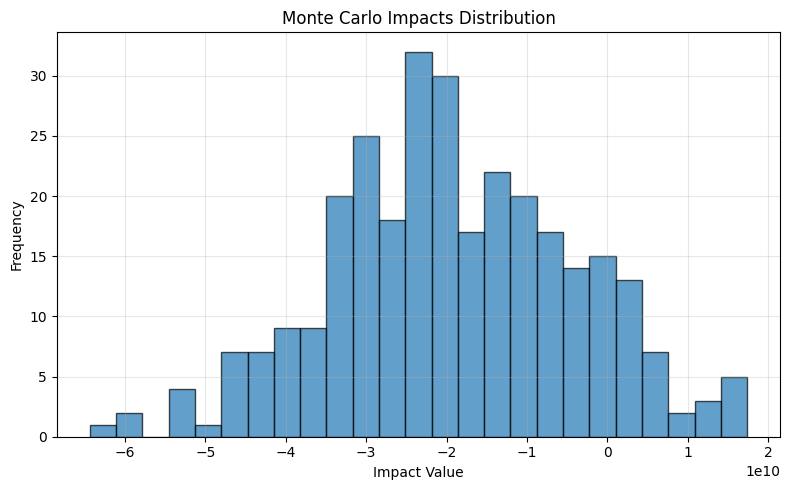


MONTE CARLO ANALYSIS RESULTS

Impact Statistics:
------------------------------------------------------------
count    3.000000e+02
mean    -1.924723e+10
std      1.523512e+10
min     -6.436308e+10
25%     -3.026579e+10
50%     -2.006963e+10
75%     -8.547157e+09
max      1.738026e+10
Name: Impact Value, dtype: float64

Top Choices (by frequency):
------------------------------------------------------------
                                                               times_chosen  \
technology process                                                            
methane    market for biomethane | biomethane, 24 bar | RER             298   
biogas     anaerobic digestion of agricultural residues | ...           287   
           anaerobic digestion of sequential crop | biogas...           282   
ammonia    nitrogen + hydrogen | ammonia | RER                          276   
biomethane upgrading chemical scrubbing (CCS) | biomethane...           269   
hydrogen   steam methane reforming 

In [11]:
# Check if MC results with normal distributions already exist
if check_file_exists(MC_NORMAL_FILE):
    print(f"Loading existing MC results (normal) from {MC_NORMAL_FILE}...")
    mc_normal_results = load_results(MC_NORMAL_FILE)
else:
    print(f"Running Monte Carlo analysis with fitted normal distributions ({N_MC_ITERATIONS} iterations)...")
    
    # Re-instantiate problem for MC
    pulpo_worker.instantiate(demand=demand, choices=choices, upper_limit=upper_bounds)
    
    # Define uncertainty strategies (same as before)
    unc_strategies = [
        processor.TriangularBoundInterpolationStrategy(
            uncertain_param_type='If',
            uncertain_param_subgroup='ecoinvent-3.10-cutoff',
            noise_interval={'min': 0.1, 'max': 0.1}
        ),
        processor.UniformBaseStrategy(
            uncertain_param_type='If',
            uncertain_param_subgroup='ammonia',
            upper_scaling_factor=0.5,
            lower_scaling_factor=0.5,
            noise_interval={'min': 0.2, 'max': 0.2}
        ),
        processor.ExpertKnowledgeStrategy(
            uncertain_param_type='If',
            uncertain_param_subgroup='ammonia',
            prob_metadata={
                (715, 23523): {'loc': -2.622585, 'scale': 0.8, 'uncertainty_type': 2}, # CO2 emissions from [CCS 200km pipeline 1000m deep]
                (81, 23537): {'loc': -5.171644, 'scale': 0.1, 'uncertainty_type': 2}, # Carbon dioxide, in air | ('natural resource', 'in air')
                (82, 23537): {'loc': -4.678482, 'scale': 0.1, 'uncertainty_type': 2}, # Carbon dioxide, non-fossil | ('air', 'urban air close to ground')
                (716, 23537): {'loc': -2.718564, 'scale': 0.1, 'uncertainty_type': 2}, # Carbon dioxide, fossil | ('air', 'non-urban air or from high stacks')
            }
        )
    ]
    
    # Import and filter uncertainty data
    pulpo_worker.import_and_filter_uncertainty_data(
        cutoff=UNCERTAINTY_CUTOFF,
        scaling_vector_strategy='constructed_demand',
        plot_results=False,
        plot_n_top_processes=N_TOP_PROCESSES
    )
    
    # Apply uncertainty strategies
    pulpo_worker.apply_uncertainty_strategies(strategies=unc_strategies, drop_undefined=True)
    
    # Transform distributions to normal
    pulpo_worker.uncertainty_data = processor.transform_to_normal(
        pulpo_worker.uncertainty_data,
        sample_size=100,
        plot_distribution=False
    )
    
    # Run Monte Carlo
    mc_normal_results = pulpo_worker.run_mc_from_uncertainty(
        n_samples=N_MC_ITERATIONS,
        seed=RANDOM_SEED,
        solver_name=SOLVER_NAME,
        options=None
    )
    
    # Save results
    save_results(mc_normal_results, MC_NORMAL_FILE)
    
    print("✓ MC analysis with normal distributions completed!")

# Analyze and visualize results
print("\nAnalyzing MC results with fitted normal distributions...")
analysis_normal = analyze_MC_results(mc_normal_results, show_plot=True)

## 5. Monte Carlo Analysis - Ecoinvent Uncertainties Only (B and Q)

This section runs Monte Carlo simulations using only the original Ecoinvent uncertainty information (B and Q matrices), without custom strategies.

Loading existing MC results (ecoinvent) from data/results/mc_ecoinvent_only.pkl...
✓ Results loaded from: data/results/mc_ecoinvent_only.pkl

Analyzing MC results with Ecoinvent uncertainties only...
✓ Results loaded from: data/results/mc_ecoinvent_only.pkl

Analyzing MC results with Ecoinvent uncertainties only...


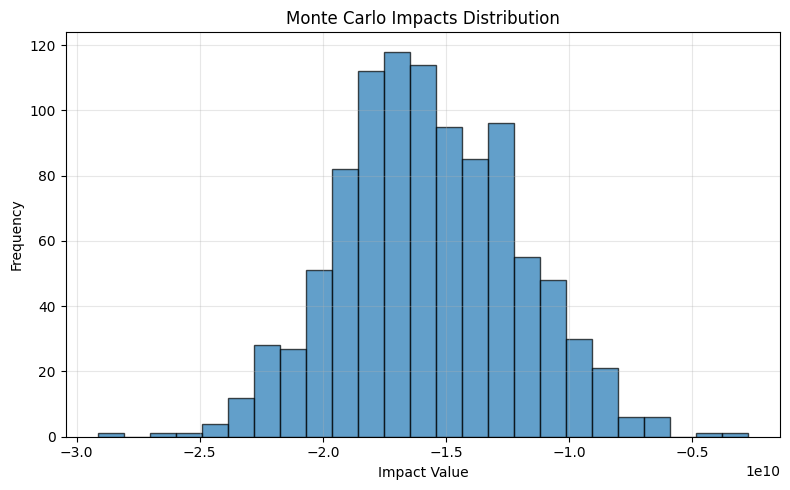


MONTE CARLO ANALYSIS RESULTS

Impact Statistics:
------------------------------------------------------------
count    9.950000e+02
mean    -1.569682e+10
std      3.597979e+09
min     -2.912519e+10
25%     -1.811617e+10
50%     -1.592361e+10
75%     -1.310521e+10
max     -2.757335e+09
Name: Impact Value, dtype: float64

Top Choices (by frequency):
------------------------------------------------------------
                                                               times_chosen  \
technology process                                                            
ammonia    nitrogen + hydrogen | ammonia | RER                          995   
           steam reforming, integrated (CCS) | ammonia | RER            995   
biogas     anaerobic digestion of agricultural residues | ...           995   
           anaerobic digestion of sequential crop | biogas...           995   
heat       heat from methane (CCS) | heat | RER                         995   
hydrogen   steam methane reforming 

In [12]:
# Check if MC results with ecoinvent only already exist
if check_file_exists(MC_ECOINVENT_FILE):
    print(f"Loading existing MC results (ecoinvent) from {MC_ECOINVENT_FILE}...")
    mc_ecoinvent_results = load_results(MC_ECOINVENT_FILE)
else:
    print(f"Running Monte Carlo analysis with Ecoinvent uncertainties only ({N_MC_ITERATIONS} iterations)...")
    
    # Re-instantiate problem for MC
    pulpo_worker.instantiate(demand=demand, choices=choices, upper_limit=upper_bounds)
    
    # Run Monte Carlo using only B and Q matrices from Ecoinvent
    mc_ecoinvent_results = pulpo_worker.solve_MC(
        n_it=N_MC_ITERATIONS, 
        GAMS_PATH=False, 
        solver_name=SOLVER_NAME, 
        resample=('B', 'Q')
    )
    
    # Save results
    save_results(mc_ecoinvent_results, MC_ECOINVENT_FILE)
    
    print("✓ MC analysis with Ecoinvent uncertainties completed!")

# Analyze and visualize results
print("\nAnalyzing MC results with Ecoinvent uncertainties only...")
analysis_ecoinvent = analyze_MC_results(mc_ecoinvent_results, show_plot=True)

## 6. Comparative Analysis of Results

Compare the results from all three Monte Carlo approaches.

In [13]:
# Create comparative summary
print("\n" + "="*80)
print("COMPARATIVE ANALYSIS - ALL MONTE CARLO APPROACHES")
print("="*80)

comparison_data = {
    'Approach': [
        'Custom Strategies',
        'Fitted Normal',
        'Ecoinvent Only'
    ],
    'Mean Impact': [
        analysis_strategies['impact_stats']['mean'],
        analysis_normal['impact_stats']['mean'],
        analysis_ecoinvent['impact_stats']['mean']
    ],
    'Std Dev': [
        analysis_strategies['impact_stats']['std'],
        analysis_normal['impact_stats']['std'],
        analysis_ecoinvent['impact_stats']['std']
    ],
    'Min Impact': [
        analysis_strategies['impact_stats']['min'],
        analysis_normal['impact_stats']['min'],
        analysis_ecoinvent['impact_stats']['min']
    ],
    'Max Impact': [
        analysis_strategies['impact_stats']['max'],
        analysis_normal['impact_stats']['max'],
        analysis_ecoinvent['impact_stats']['max']
    ],
    'CV (%)': [
        (analysis_strategies['impact_stats']['std'] / analysis_strategies['impact_stats']['mean']) * 100,
        (analysis_normal['impact_stats']['std'] / analysis_normal['impact_stats']['mean']) * 100,
        (analysis_ecoinvent['impact_stats']['std'] / analysis_ecoinvent['impact_stats']['mean']) * 100
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n", comparison_df.to_string(index=False))
print("\n" + "="*80)


COMPARATIVE ANALYSIS - ALL MONTE CARLO APPROACHES

          Approach   Mean Impact      Std Dev    Min Impact    Max Impact     CV (%)
Custom Strategies -1.654619e+10 1.651506e+10 -5.709002e+10  1.767331e+10 -99.811895
    Fitted Normal -1.924723e+10 1.523512e+10 -6.436308e+10  1.738026e+10 -79.154862
   Ecoinvent Only -1.569682e+10 3.597979e+09 -2.912519e+10 -2.757335e+09 -22.921709



## 7. Combined Visualization

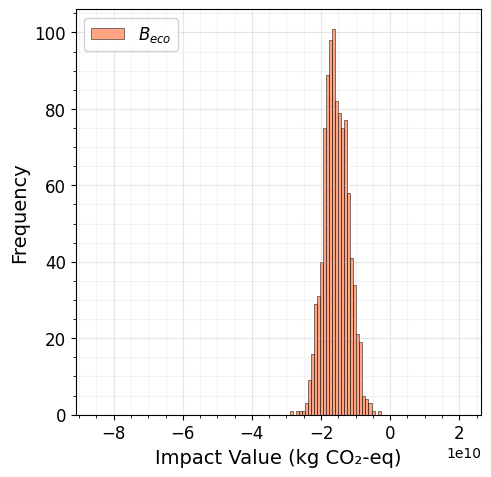

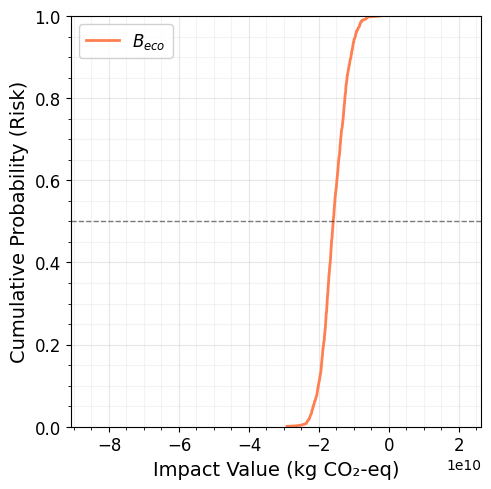

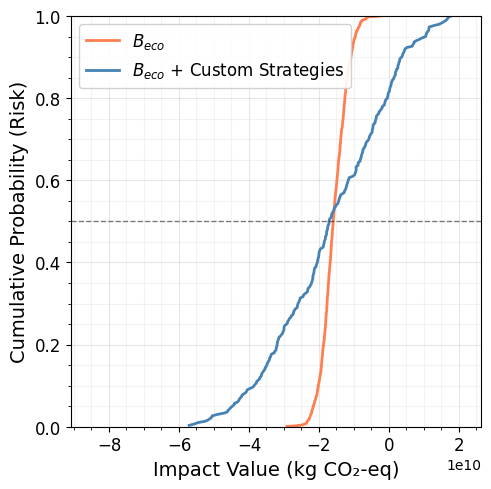

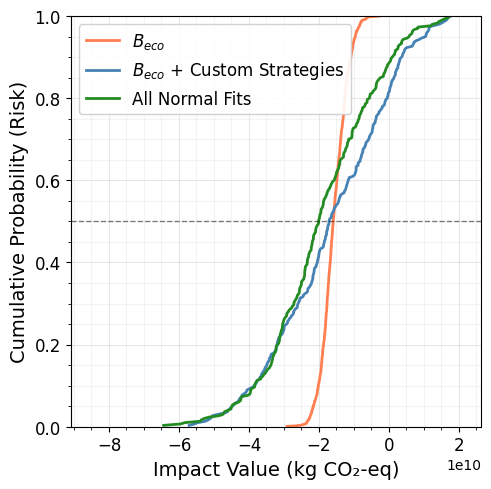

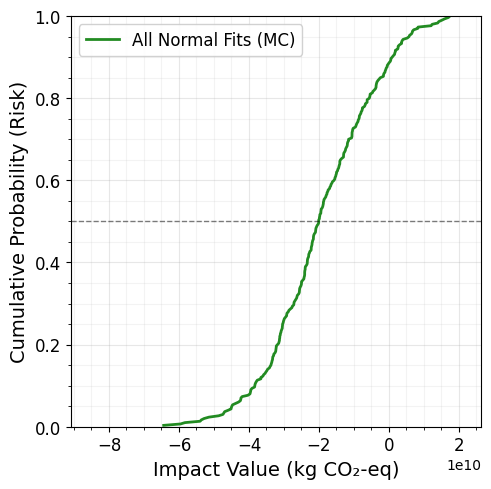

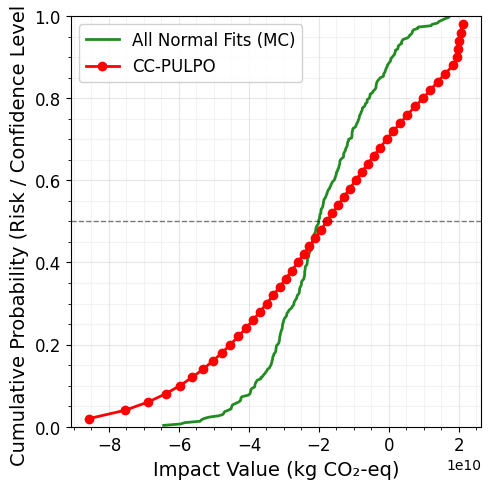


✓ Six progressive comparison plots saved:
  1. data/results/mc_comparison_1_histogram.png - Ecoinvent histogram
  2. data/results/mc_comparison_2_cumulative_eco.png - Ecoinvent cumulative risk
  3. data/results/mc_comparison_3_cumulative_strategies.png - + Custom strategies
  4. data/results/mc_comparison_4_cumulative_all.png - + Normal fits
  5. data/results/mc_comparison_5_cumulative_normal.png - Normal fits only
  6. data/results/mc_comparison_6_cc_vs_mc.png - CC-Pareto vs MC comparison


In [30]:
import numpy as np
import matplotlib.pyplot as plt

# === Calculate consistent axis ranges for all plots ===
all_values = np.concatenate([
    analysis_ecoinvent['impact_values'],
    analysis_strategies['impact_values'], 
    analysis_normal['impact_values']
])

# Prepare CC-Pareto data for cumulative risk plotting
cc_lambda_vals = []
cc_impact_vals = []
for lambda_eps in cc_pareto_results['lambda_epsilon_array']:
    if lambda_eps in cc_pareto_results['results_CC']:
        result = cc_pareto_results['results_CC'][lambda_eps]
        if "Impacts" in result and not result["Impacts"].empty:
            impact_value = result["Impacts"].iloc[0, 1]  # Value column
            cc_lambda_vals.append(lambda_eps)
            cc_impact_vals.append(impact_value)

# Include CC-Pareto results in the x-axis range calculation
if cc_impact_vals:
    all_values_including_cc = np.concatenate([all_values, cc_impact_vals])
else:
    all_values_including_cc = all_values

x_min, x_max = all_values_including_cc.min(), all_values_including_cc.max()
x_range = x_max - x_min
x_min_plot = x_min - 0.05 * x_range
x_max_plot = x_max + 0.05 * x_range

# Sort CC data by impact value for proper cumulative plotting
cc_sorted_data = sorted(zip(cc_impact_vals, cc_lambda_vals))
cc_impacts_sorted, cc_lambdas_sorted = zip(*cc_sorted_data) if cc_sorted_data else ([], [])

# === Utility function for consistent plot styling ===
def format_plot(ax, xlabel, ylabel, xlim, ylim=None):
    ax.set_xlabel(xlabel, fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)
    ax.grid(True, alpha=0.3, which='major')
    ax.grid(True, alpha=0.15, which='minor')
    ax.minorticks_on()
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.tick_params(axis='both', which='minor', labelsize=10)
    # Make the drawing area a square (equal physical length)
    ax.set_box_aspect(1)
    plt.tight_layout()

# === Figure 1: Histogram of Ecoinvent Results ===
fig, ax = plt.subplots(figsize=(5, 5))  # 85 mm width
ax.hist(analysis_ecoinvent['impact_values'], bins=30, alpha=0.7, color='coral', 
        label='$B_{eco}$', edgecolor='black', linewidth=0.5)
format_plot(ax, 'Impact Value (kg CO₂-eq)', 'Frequency', (x_min_plot, x_max_plot))
ax.legend(loc='upper left', framealpha=0.9, fontsize=12)
plt.savefig(f'{RESULTS_DIR}/mc_comparison_1_histogram.png', dpi=300, bbox_inches='tight')
plt.show()

# === Figure 2: Cumulative Risk of Ecoinvent Results ===
fig, ax = plt.subplots(figsize=(5, 5))
sorted_eco = np.sort(analysis_ecoinvent['impact_values'])
cumulative_prob_eco = np.arange(1, len(sorted_eco) + 1) / len(sorted_eco)
ax.plot(sorted_eco, cumulative_prob_eco, color='coral', linewidth=2, 
        label='$B_{eco}$')
ax.axhline(y=0.5, color='black', linestyle='--', alpha=0.5, linewidth=1)
format_plot(ax, 'Impact Value (kg CO₂-eq)', 'Cumulative Probability (Risk)', 
            (x_min_plot, x_max_plot), (0, 1))
ax.legend(loc='upper left', framealpha=0.9, fontsize=12)
plt.savefig(f'{RESULTS_DIR}/mc_comparison_2_cumulative_eco.png', dpi=300, bbox_inches='tight')
plt.show()

# === Figure 3: Add Custom Strategies to Cumulative Risk ===
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(sorted_eco, cumulative_prob_eco, color='coral', linewidth=2, 
        label='$B_{eco}$')
sorted_strat = np.sort(analysis_strategies['impact_values'])
cumulative_prob_strat = np.arange(1, len(sorted_strat) + 1) / len(sorted_strat)
ax.plot(sorted_strat, cumulative_prob_strat, color='steelblue', linewidth=2, 
        label='$B_{eco}$ + Custom Strategies')
ax.axhline(y=0.5, color='black', linestyle='--', alpha=0.5, linewidth=1)
format_plot(ax, 'Impact Value (kg CO₂-eq)', 'Cumulative Probability (Risk)', 
            (x_min_plot, x_max_plot), (0, 1))
ax.legend(loc='upper left', framealpha=0.9, fontsize=12)
plt.savefig(f'{RESULTS_DIR}/mc_comparison_3_cumulative_strategies.png', dpi=300, bbox_inches='tight')
plt.show()

# === Figure 4: Add Normal Fits to Cumulative Risk ===
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(sorted_eco, cumulative_prob_eco, color='coral', linewidth=2, 
        label='$B_{eco}$')
ax.plot(sorted_strat, cumulative_prob_strat, color='steelblue', linewidth=2, 
        label='$B_{eco}$ + Custom Strategies')
sorted_norm = np.sort(analysis_normal['impact_values'])
cumulative_prob_norm = np.arange(1, len(sorted_norm) + 1) / len(sorted_norm)
ax.plot(sorted_norm, cumulative_prob_norm, color='forestgreen', linewidth=2, 
        label='All Normal Fits')
ax.axhline(y=0.5, color='black', linestyle='--', alpha=0.5, linewidth=1)
format_plot(ax, 'Impact Value (kg CO₂-eq)', 'Cumulative Probability (Risk)', 
            (x_min_plot, x_max_plot), (0, 1))
ax.legend(loc='upper left', framealpha=0.9, fontsize=12)
plt.savefig(f'{RESULTS_DIR}/mc_comparison_4_cumulative_all.png', dpi=300, bbox_inches='tight')
plt.show()

# === Figure 5: Only Normal Fits Cumulative Risk ===
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(sorted_norm, cumulative_prob_norm, color='forestgreen', linewidth=2, 
        label='All Normal Fits (MC)')
ax.axhline(y=0.5, color='black', linestyle='--', alpha=0.5, linewidth=1)
format_plot(ax, 'Impact Value (kg CO₂-eq)', 'Cumulative Probability (Risk)', 
            (x_min_plot, x_max_plot), (0, 1))
ax.legend(loc='upper left', framealpha=0.9, fontsize=12)
plt.savefig(f'{RESULTS_DIR}/mc_comparison_5_cumulative_normal.png', dpi=300, bbox_inches='tight')
plt.show()

# === Figure 6: Compare Normal Fits MC with CC-Pareto Results ===
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(sorted_norm, cumulative_prob_norm, color='forestgreen', linewidth=2, 
        label='All Normal Fits (MC)')
if cc_impacts_sorted and cc_lambdas_sorted:
    ax.plot(cc_impacts_sorted, cc_lambdas_sorted, color='red', linewidth=2, 
            marker='o', markersize=6, label='CC-PULPO')
ax.axhline(y=0.5, color='black', linestyle='--', alpha=0.5, linewidth=1)
format_plot(ax, 'Impact Value (kg CO₂-eq)', 
            'Cumulative Probability (Risk / Confidence Level λ)', 
            (x_min_plot, x_max_plot), (0, 1))
ax.legend(loc='upper left', framealpha=0.9, fontsize=12)
plt.savefig(f'{RESULTS_DIR}/mc_comparison_6_cc_vs_mc.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Six progressive comparison plots saved:")
print(f"  1. {RESULTS_DIR}/mc_comparison_1_histogram.png - Ecoinvent histogram")
print(f"  2. {RESULTS_DIR}/mc_comparison_2_cumulative_eco.png - Ecoinvent cumulative risk")
print(f"  3. {RESULTS_DIR}/mc_comparison_3_cumulative_strategies.png - + Custom strategies")
print(f"  4. {RESULTS_DIR}/mc_comparison_4_cumulative_all.png - + Normal fits")
print(f"  5. {RESULTS_DIR}/mc_comparison_5_cumulative_normal.png - Normal fits only")
print(f"  6. {RESULTS_DIR}/mc_comparison_6_cc_vs_mc.png - CC-Pareto vs MC comparison")


## 8. Choice Analysis within Risk Ranges

This section analyzes which technology choices were selected for Monte Carlo results that fall within specific risk ranges, providing insights into optimal technology pathways under different risk scenarios.

In [53]:
# ===============================================
# CHOICE ANALYSIS WITHIN RISK RANGES
# ===============================================

def analyze_choices_in_risk_range(mc_results, analysis_data, risk_min=0.2, risk_max=0.8, label="Normal Fits"):
    """
    Analyze technology choices for Monte Carlo results within a risk range.
    """
    impacts = np.sort(analysis_data['impact_values'])
    n = len(impacts)
    i_min, i_max = int(risk_min * n), min(int(risk_max * n), n - 1)
    imp_min, imp_max = impacts[i_min], impacts[i_max]

    print(f"\n{label} — Risk {risk_min:.0%}–{risk_max:.0%} | Impact range: [{imp_min:.2e}, {imp_max:.2e}] kg CO₂-eq")

    # Filter iterations within the risk range
    valid_iters = [
        it['Choices'] for it in mc_results.values()
        if isinstance(it, dict)
        and imp_min <= it['Impacts'].iloc[0, 1] <= imp_max
    ]

    if not valid_iters:
        print("No iterations found in this risk range.")
        return None

    print(f"Found {len(valid_iters)} iterations in range.")

    # Count technology choices
    counts = {}
    for choices in valid_iters:
        for cat, tech in choices.items():
            tech_name = tech[0] if isinstance(tech, tuple) else str(tech)
            counts.setdefault(cat, {}).setdefault(tech_name, 0)
            counts[cat][tech_name] += 1

    # Report percentages
    total = len(valid_iters)
    for cat, techs in counts.items():
        print(f"\n{cat.upper()} Technology Choices:")
        for t, c in sorted(techs.items(), key=lambda x: x[1], reverse=True):
            print(f"  {t}: {c}/{total} ({c / total * 100:.1f}%)")

    return dict(
        risk_range=(risk_min, risk_max),
        impact_range=(imp_min, imp_max),
        n_samples=total,
        choice_counts=counts
    )


# === Run analyses for defined risk ranges ===
print("=" * 80)
print("CHOICE ANALYSIS FOR DIFFERENT RISK SCENARIOS")
print("=" * 80)

risk_ranges = [(0.5, 0.6), (0.6, 0.7), (0.7, 0.8), (0.8, 0.9), (0.9, 0.95), (0.95, 1.0)]

risk_analysis_results = {
    f"{int(a*100)}%-{int(b*100)}%": res
    for (a, b) in risk_ranges
    if (res := analyze_choices_in_risk_range(mc_normal_results, analysis_normal, a, b, f"{int(a*100)}%-{int(b*100)}%"))
}

print("\n" + "=" * 80)
print("CHOICE ANALYSIS COMPLETE")
print("=" * 80)


CHOICE ANALYSIS FOR DIFFERENT RISK SCENARIOS

50%-60% — Risk 50%–60% | Impact range: [-2.01e+10, -1.55e+10] kg CO₂-eq
Found 31 iterations in range.

BIOGAS Technology Choices:
                                                             Value      Capacity
Metadata                                                                      
anaerobic digestion of agricultural residues | ...  1.600000e+10  1.600000e+10
anaerobic digestion of sequential crop | biogas...  1.400000e+10  1.400000e+10: 29/31 (93.5%)
                                                             Value      Capacity
Metadata                                                                      
anaerobic digestion of agricultural residues | ...  1.600000e+10  1.600000e+10
anaerobic digestion of sequential crop | biogas... -0.000000e+00  1.400000e+10: 2/31 (6.5%)

BIOMETHANE Technology Choices:
                                                             Value      Capacity
Metadata                                       

Choice analysis plot saved to: data/results/choice_analysis_by_risk.png


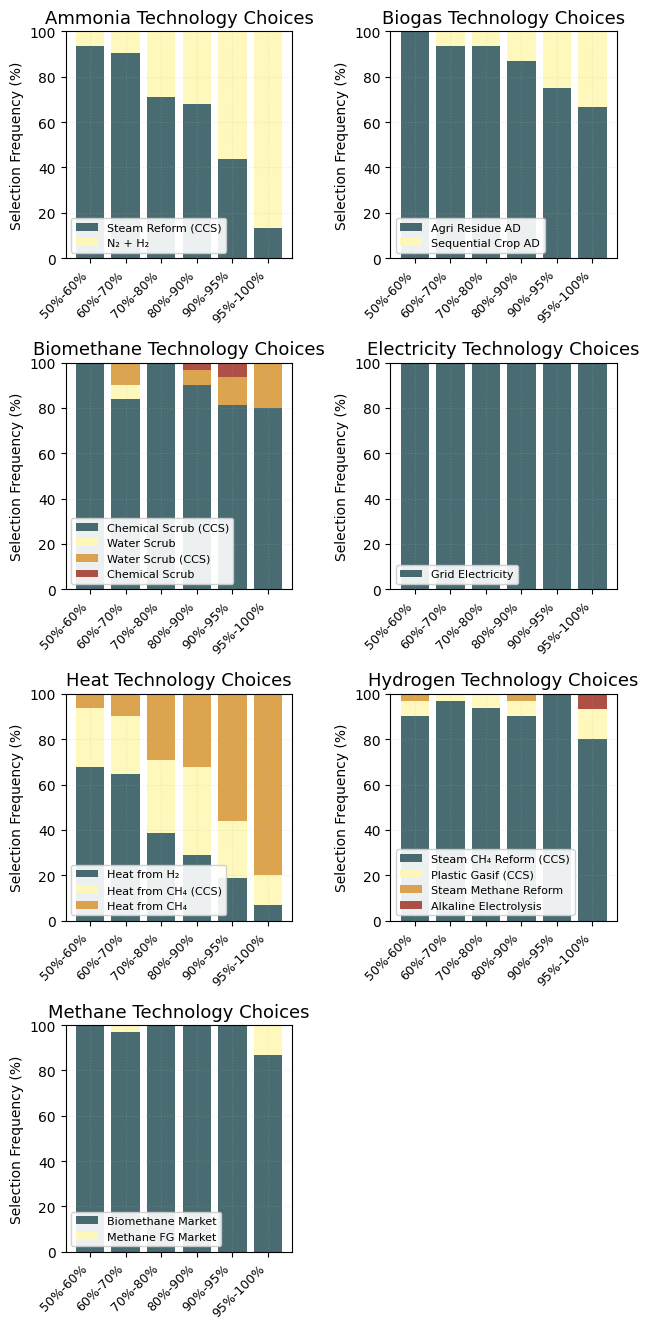


✓ Choice analysis visualization saved to: data/results/choice_analysis_by_risk.png


In [65]:
# ===============================================
# CHOICE ANALYSIS VISUALIZATION
# ===============================================

def plot_choice_analysis(results, save_path=None):
    """Plot technology choice frequencies across risk ranges using a harmonized warm palette."""
    if not results:
        print("No analysis results to plot.")
        return

    categories = sorted({c for r in results.values() for c in r['choice_counts']})
    risk_labels = list(results.keys())
    n_cat = len(categories)

    def clean_name(name):
        if isinstance(name, str) and "Metadata" in name:
            lines = [l.split('|')[0].strip() for l in name.splitlines()
                     if '|' in l and 'Metadata' not in l and 'Value' not in l]
            return lines[0] if lines else "Unknown Technology"
        return name[0] if isinstance(name, tuple) else str(name)

    # --- Layout: multi-column grid ---
    n_cols = 2
    n_rows = int(np.ceil(n_cat / n_cols))
    fig_width_in = 3.35 * n_cols
    fig_height_in = 3.35 * n_rows
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width_in, fig_height_in))
    axes = np.atleast_1d(axes).ravel()

    # --- Harmonized warm color palette (from your image) ---
    palette = ["#355C63", "#FFF8B5", "#D99A3C", "#A53D31", "#4E1512"]

    for ax, cat in zip(axes, categories):
        tech_data = {}
        for risk_name, res in results.items():
            for raw_name, count in res['choice_counts'].get(cat, {}).items():
                name = clean_name(raw_name)
                tech_data.setdefault(name, {}).setdefault(risk_name, 0)
                tech_data[name][risk_name] += count / res['n_samples'] * 100

        if not tech_data:
            ax.axis("off")
            continue

        x = np.arange(len(risk_labels))
        bottom = np.zeros(len(risk_labels))

        tech_names = list(tech_data.items())
        for i, (name, vals) in enumerate(tech_names):
            y = [vals.get(r, 0) for r in risk_labels]
            display_name = label_shortening_map.get(name, name).replace('_', ' ')
            color = palette[i % len(palette)]
            ax.bar(x, y, bottom=bottom, label=display_name, color=color, alpha=0.9)
            bottom += y

        # --- Formatting ---
        ax.set_title(f"{cat.title()} Technology Choices", fontsize=13, fontweight='normal')
        ax.set_xticks(x)
        ax.set_xticklabels(risk_labels, rotation=45, ha='right', fontsize=9)
        ax.set_ylabel("Selection Frequency (%)", fontsize=10)
        ax.set_ylim(0, 100)
        ax.grid(True, alpha=0.25, linestyle=':')
        ax.set_box_aspect(1)

        # Legend always shown, inside lower-left
        ax.legend(loc="lower left", fontsize=8, framealpha=0.9, ncol=1)

    # Hide unused axes
    for ax in axes[len(categories):]:
        ax.axis("off")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Choice analysis plot saved to: {save_path}")
    plt.show()





# === Create Label Shortening Map ===
label_shortening_map = {
    # AMMONIA Technologies
    'nitrogen + hydrogen': 'N₂ + H₂',
    'steam reforming, integrated (CCS)': 'Steam Reform (CCS)',
    
    # BIOGAS Technologies  
    'anaerobic digestion of agricultural residues': 'Agri Residue AD',
    'anaerobic digestion of sequential crop': 'Sequential Crop AD',
    
    # BIOMETHANE Technologies
    'upgrading chemical scrubbing': 'Chemical Scrub',
    'upgrading chemical scrubbing (CCS)': 'Chemical Scrub (CCS)',
    'upgrading water scrubbing': 'Water Scrub',
    'upgrading water scrubbing (CCS)': 'Water Scrub (CCS)',
    
    # ELECTRICITY Technologies
    'grid electricity': 'Grid Electricity',
    
    # HEAT Technologies
    'heat from hydrogen': 'Heat from H₂',
    'heat from methane': 'Heat from CH₄',
    'heat from methane (CCS)': 'Heat from CH₄ (CCS)',
    
    # HYDROGEN Technologies
    'alkaline electrolysis': 'Alkaline Electrolysis',
    'plastics gasification (CCS)': 'Plastic Gasif (CCS)',
    'steam methane reforming': 'Steam Methane Reform',
    'steam methane reforming (CCS)': 'Steam CH₄ Reform (CCS)',
    
    # METHANE Technologies
    'market for biomethane': 'Biomethane Market',
    'market for methane fg': 'Methane FG Market'
}

# === Visualization ===
plot_choice_analysis(risk_analysis_results, f"{RESULTS_DIR}/choice_analysis_by_risk.png")

print(f"\n✓ Choice analysis visualization saved to: {RESULTS_DIR}/choice_analysis_by_risk.png")

In [40]:
print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)
print(f"\nTotal iterations per approach: {N_MC_ITERATIONS}")
print(f"Random seed: {RANDOM_SEED}")
print(f"Solver: {SOLVER_NAME}")
print(f"\nAll results saved to: {RESULTS_DIR}")
print("\nFiles generated:")
print(f"  1. {CC_PARETO_FILE}")
print(f"  2. {MC_STRATEGIES_FILE}")
print(f"  3. {MC_NORMAL_FILE}")
print(f"  4. {MC_ECOINVENT_FILE}")
print(f"  5. {RESULTS_DIR}/mc_comparison_*.png (6 cumulative risk plots)")
print(f"  6. {RESULTS_DIR}/choice_analysis_by_risk.png")
print("\nAnalysis Components:")
print("  ✓ Chance-Constrained Pareto Optimization")
print("  ✓ Monte Carlo Analysis (3 approaches)")
print("  ✓ Cumulative Risk Comparison")
print("  ✓ Technology Choice Analysis by Risk Range")
print("\n" + "="*80)
print("\n✓ Notebook execution completed successfully!")


ANALYSIS COMPLETE

Total iterations per approach: 300
Random seed: 666
Solver: highs

All results saved to: data/results

Files generated:
  1. data/results/cc_pareto_results.pkl
  2. data/results/mc_uncertainty_strategies.pkl
  3. data/results/mc_fitted_normal.pkl
  4. data/results/mc_ecoinvent_only.pkl
  5. data/results/mc_comparison_*.png (6 cumulative risk plots)
  6. data/results/choice_analysis_by_risk.png

Analysis Components:
  ✓ Chance-Constrained Pareto Optimization
  ✓ Monte Carlo Analysis (3 approaches)
  ✓ Cumulative Risk Comparison
  ✓ Technology Choice Analysis by Risk Range


✓ Notebook execution completed successfully!


In [45]:
# Choice Analysis Summary
print("\n" + "="*50)
print("CHOICE ANALYSIS SUMMARY")
print("="*50)
print("✓ Analyzed technology choices across 4 risk ranges")
print("✓ Identified optimal technology pathways for different risk scenarios")
print("✓ Generated visualization showing choice frequency patterns")
print(f"✓ Results saved to: {RESULTS_DIR}/choice_analysis_by_risk.png")
print("="*50)


CHOICE ANALYSIS SUMMARY
✓ Analyzed technology choices across 4 risk ranges
✓ Identified optimal technology pathways for different risk scenarios
✓ Generated visualization showing choice frequency patterns
✓ Results saved to: data/results/choice_analysis_by_risk.png
